In [32]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

In [15]:
file_path = "/Users/anshulraghu/Desktop/Spring2026/EGN 6217/Project/data/Personal_Finance_Dataset.csv"
df = pd.read_csv(file_path)
df.head()

,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


In [16]:
df = df.dropna()

df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(by='Date')

df.head()

,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


In [17]:
le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['Category'])

df[['Category', 'category_encoded']].head()

,Category,category_encoded
0,Food & Drink,1
1,Utilities,9
2,Rent,5
3,Investment,3
4,Food & Drink,1


In [18]:
def create_sequences(data, seq_length=5):
    sequences = []
    labels = []

    values = data['category_encoded'].values

    for i in range(len(values) - seq_length):
        seq = values[i:i+seq_length]
        label = values[i+seq_length]

        sequences.append(seq)
        labels.append(label)

    return np.array(sequences), np.array(labels)

X, y = create_sequences(df, seq_length=5)

print(X.shape, y.shape)

(1495, 5) (1495,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# reshape for LSTM: (batch, seq, features)
X_train = X_train.reshape(-1, 5, 1)
X_test = X_test.reshape(-1, 5, 1)

In [20]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

In [21]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, len(le.classes_))

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = LSTMModel()

In [22]:
class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, len(le.classes_))

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)

In [23]:
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Linear(1, 32)

        encoder_layer = nn.TransformerEncoderLayer(d_model=32, nhead=2)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.fc = nn.Linear(32, len(le.classes_))

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        x = x[:, -1, :]
        return self.fc(x)

In [24]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    losses = []

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    # Evaluation
    model.eval()
    with torch.no_grad():
        preds = model(X_test)
        predicted_classes = torch.argmax(preds, axis=1)

    acc = accuracy_score(y_test, predicted_classes)
    f1 = f1_score(y_test, predicted_classes, average='weighted')

    return acc, f1, losses

In [25]:
# LSTM
lstm_model = LSTMModel()
lstm_acc, lstm_f1, lstm_losses = train_and_evaluate(
    lstm_model, X_train, y_train, X_test, y_test
)

# GRU
gru_model = GRUModel()
gru_acc, gru_f1, gru_losses = train_and_evaluate(
    gru_model, X_train, y_train, X_test, y_test
)

# Transformer
transformer_model = TransformerModel()
trans_acc, trans_f1, trans_losses = train_and_evaluate(
    transformer_model, X_train, y_train, X_test, y_test
)

print("\nFinal Results:")
print("LSTM  -> Acc:", lstm_acc, "F1:", lstm_f1)
print("GRU   -> Acc:", gru_acc, "F1:", gru_f1)
print("TRANS -> Acc:", trans_acc, "F1:", trans_f1)

Epoch 1, Loss: 2.3119
Epoch 2, Loss: 2.3105
Epoch 3, Loss: 2.3092
Epoch 4, Loss: 2.3080
Epoch 5, Loss: 2.3069
Epoch 6, Loss: 2.3058
Epoch 7, Loss: 2.3049
Epoch 8, Loss: 2.3040
Epoch 9, Loss: 2.3031
Epoch 10, Loss: 2.3024
Epoch 1, Loss: 2.3210
Epoch 2, Loss: 2.3170
Epoch 3, Loss: 2.3136
Epoch 4, Loss: 2.3106
Epoch 5, Loss: 2.3081
Epoch 6, Loss: 2.3060
Epoch 7, Loss: 2.3043
Epoch 8, Loss: 2.3029
Epoch 9, Loss: 2.3018
Epoch 10, Loss: 2.3010


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1, Loss: 2.4323
Epoch 2, Loss: 2.4010
Epoch 3, Loss: 2.3607
Epoch 4, Loss: 2.3394
Epoch 5, Loss: 2.3179
Epoch 6, Loss: 2.3213
Epoch 7, Loss: 2.3166
Epoch 8, Loss: 2.3180
Epoch 9, Loss: 2.3089
Epoch 10, Loss: 2.3131

Final Results:
LSTM  -> Acc: 0.0903010033444816 F1: 0.02988088485041579
GRU   -> Acc: 0.10702341137123746 F1: 0.03575113720588876
TRANS -> Acc: 0.09364548494983277 F1: 0.039414502926756884


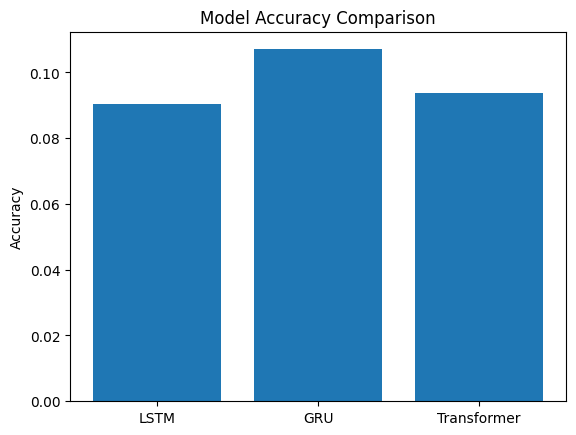

In [30]:
models = ["LSTM", "GRU", "Transformer"]
accuracies = [lstm_acc, gru_acc, trans_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.savefig("../results/accuracy_comparison.png")
plt.show()

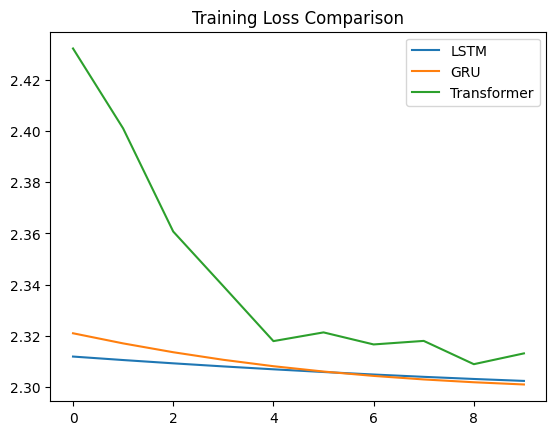

In [31]:
plt.figure()
plt.plot(lstm_losses, label="LSTM")
plt.plot(gru_losses, label="GRU")
plt.plot(trans_losses, label="Transformer")
plt.title("Training Loss Comparison")
plt.legend()
plt.savefig("../results/loss_curves.png")
plt.show()